# 函数拟合

目标函数：

$$f(x)=\sin(1.5x)+0.35\cos(4x)+0.15x^3-0.3x$$

训练标签使用带噪声观测：

$$y=f(x)+\epsilon,\ \epsilon\sim\mathcal{N}(0,0.08^2)$$

In [12]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 固定随机种子，便于复现实验
torch.manual_seed(1234)
np.random.seed(42)

# 自动选择设备（GPU 优先）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 选择可用中文字体，避免图中中文乱码
candidates = ['Microsoft YaHei', 'SimHei', 'Microsoft JhengHei', 'STSong', 'Source Han Serif SC']
available = {f.name for f in font_manager.fontManager.ttflist}
selected = next((name for name in candidates if name in available), None)
if selected is not None:
    plt.rcParams['font.sans-serif'] = [selected]
plt.rcParams['axes.unicode_minus'] = False

print('运行设备:', device)

运行设备: cuda


In [13]:
def target_function(x):
    # 目标非线性函数
    return np.sin(1.5 * x) + 0.35 * np.cos(4.0 * x) + 0.15 * (x ** 3) - 0.3 * x

def make_dataset(num_train=256, num_test=512):
    # 构造训练集与测试集，训练标签加入高斯噪声
    rng = np.random.default_rng(42)
    x_train = np.sort(rng.uniform(-3.0, 3.0, size=num_train)).astype(np.float32)
    x_test = np.linspace(-3.0, 3.0, num_test, dtype=np.float32)
    y_train = target_function(x_train) + rng.normal(0.0, 0.08, size=num_train).astype(np.float32)
    y_test = target_function(x_test).astype(np.float32)
    return x_train[:, None], y_train[:, None], x_test[:, None], y_test[:, None]

x_train_np, y_train_np, x_test_np, y_test_np = make_dataset()

# 转换为 PyTorch 张量并搬到运行设备
x_train = torch.from_numpy(x_train_np).to(device)
y_train = torch.from_numpy(y_train_np).to(device)
x_test = torch.from_numpy(x_test_np).to(device)
y_test = torch.from_numpy(y_test_np).to(device)

print('训练集形状:', x_train.shape, y_train.shape)
print('测试集形状:', x_test.shape, y_test.shape)

训练集形状: torch.Size([256, 1]) torch.Size([256, 1])
测试集形状: torch.Size([512, 1]) torch.Size([512, 1])


In [14]:
class MLP(nn.Module):
    # 可配置隐藏层层数的多层感知机
    def __init__(self, hidden_layers, width=32):
        super().__init__()
        layers = []
        in_dim = 1
        for _ in range(hidden_layers):
            layers.append(nn.Linear(in_dim, width))
            layers.append(nn.ReLU())
            in_dim = width
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_and_eval(hidden_layers, epochs=250, lr=1e-2, patience=25):
    # 训练单个模型，并使用早停保存最佳验证效果
    model = MLP(hidden_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val = float('inf')
    wait = 0
    best_state = None

    for _ in range(epochs):
        model.train()
        pred = model(x_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(x_test), y_test).item()

        if val_loss < best_val:
            best_val = val_loss
            wait = 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(x_train), y_train).item()
        test_pred = model(x_test)
        test_mse = criterion(test_pred, y_test).item()

    return {
        'layers': hidden_layers,
        'pred': test_pred.detach().cpu().numpy(),
        'train_loss': train_loss,
        'val_loss': best_val,
        'test_mse': test_mse,
    }

In [15]:
results = []
for layers in range(1, 6):
    # 每个层数单独设定随机种子，便于稳定比较
    torch.manual_seed(1234 + layers)
    result = train_and_eval(layers)
    results.append(result)
    print(
        f"hidden_layers={result['layers']} "
        f"train_loss={result['train_loss']:.6f} "
        f"val_loss={result['val_loss']:.6f} "
        f"test_mse={result['test_mse']:.6f}"
    )

hidden_layers=1 train_loss=0.062851 val_loss=0.083373 test_mse=0.083373
hidden_layers=2 train_loss=0.006138 val_loss=0.001455 test_mse=0.001455
hidden_layers=3 train_loss=0.005704 val_loss=0.001770 test_mse=0.001770
hidden_layers=4 train_loss=0.005498 val_loss=0.001744 test_mse=0.001744
hidden_layers=5 train_loss=0.006255 val_loss=0.002033 test_mse=0.002033


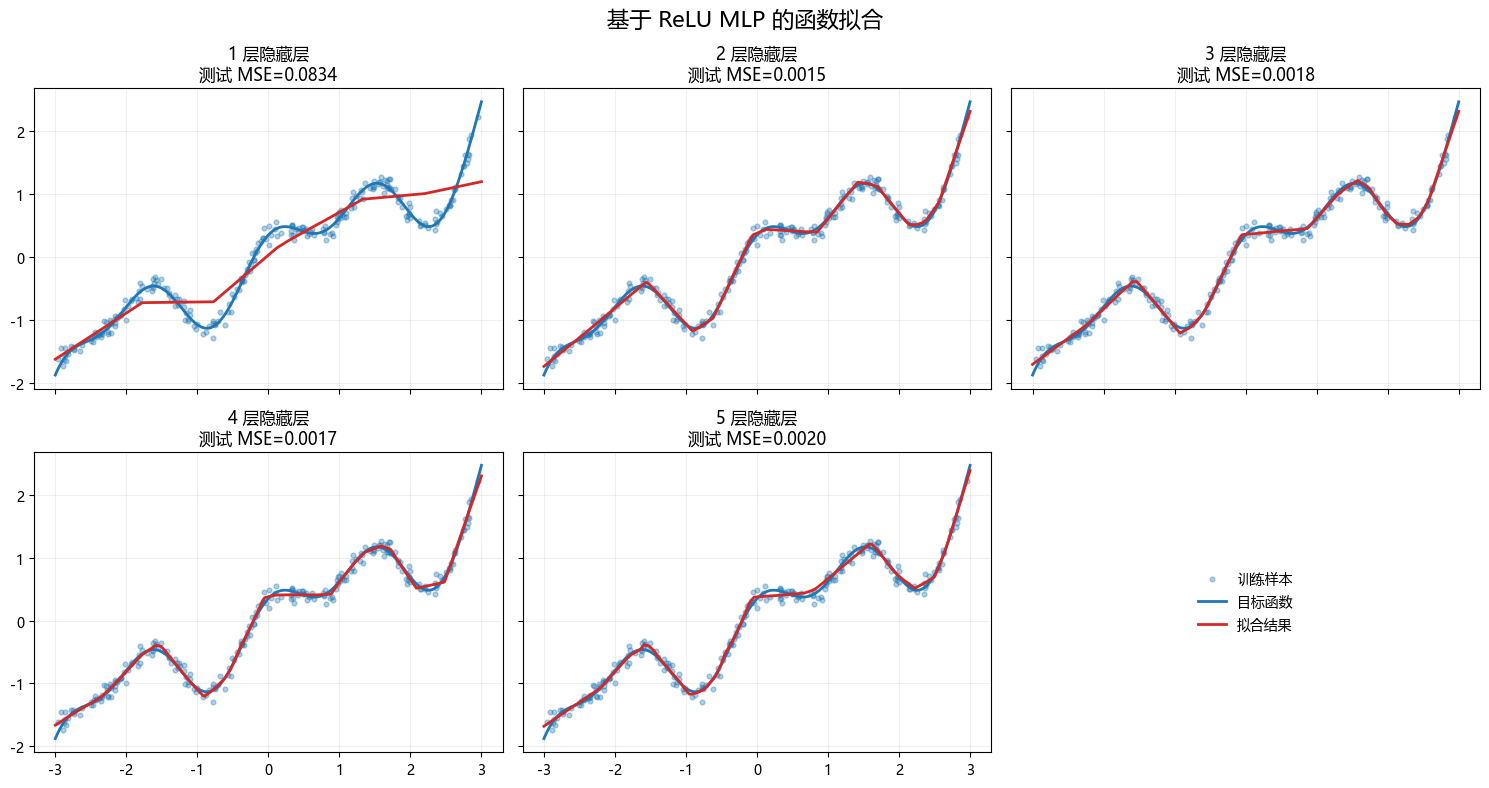

In [17]:
# 可视化 1~5 层隐藏层模型的拟合效果
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, result in zip(axes, results):
    ax.scatter(x_train_np[:, 0], y_train_np[:, 0], s=12, alpha=0.35, label='训练样本')
    ax.plot(x_test_np[:, 0], y_test_np[:, 0], color='#1f77b4', linewidth=2, label='目标函数')
    ax.plot(x_test_np[:, 0], result['pred'][:, 0], color='#d62728', linewidth=2, label='拟合结果')
    ax.set_title(f"{result['layers']} 层隐藏层\n" f"测试 MSE={result['test_mse']:.4f}")
    ax.grid(alpha=0.2)

axes[-1].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc='center', frameon=False)
fig.suptitle('基于 ReLU MLP 的函数拟合', fontsize=16)
fig.tight_layout()

fig.savefig('fitting.jpg', dpi=160, bbox_inches='tight')
plt.show()

当隐藏层从 1 层增加到 5 层时，测试误差通常会下降，说明模型的非线性拟合能力在增强。